Mean Wind Speed: 10.00 m/s
Mean Turbulence Intensity: 0.12
Weibull Fit Parameters → Shape (k): 2.16, Scale (A): 11.30


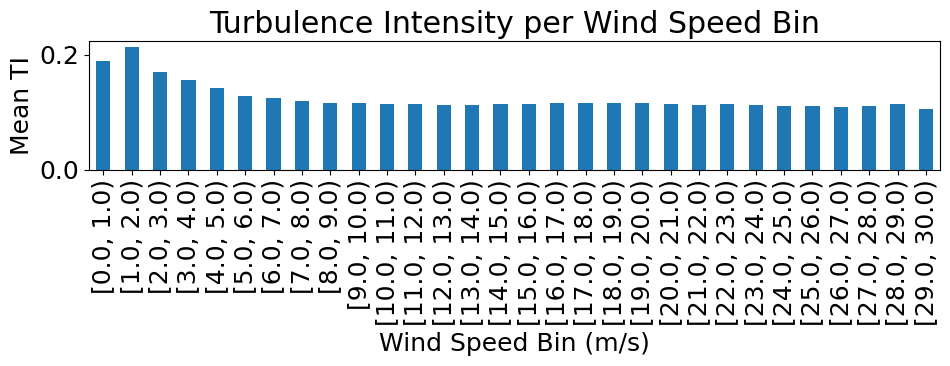

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import weibull_min
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
file_path = '/groups/SUDOCO/Task23/sudoco_task2.3/data/timeseries/HKNB_timeseries_full_filled_small_gaps_only_TI_boost.csv'  # Replace with your actual file path
df = pd.read_csv(file_path, parse_dates=['timestamp'])

# Drop rows with NaNs in wsp or TI
df = df.dropna(subset=['wsp', 'TI'])

# Basic statistics
mean_wsp = df['wsp'].mean()
mean_TI = df['TI'].mean()

print(f"Mean Wind Speed: {mean_wsp:.2f} m/s")
print(f"Mean Turbulence Intensity: {mean_TI:.2f}")

# Weibull fit (ignoring NaNs)
shape, loc, scale = weibull_min.fit(df['wsp'].values, floc=0)
print(f"Weibull Fit Parameters → Shape (k): {shape:.2f}, Scale (A): {scale:.2f}")

# TI per wind speed bin
bin_edges = np.arange(0, 30.1, 1.0)
df['wsp_bin'] = pd.cut(df['wsp'], bins=bin_edges, right=False)
ti_per_bin = df.groupby('wsp_bin', observed=True)['TI'].mean()


# Optional: plot TI vs wind speed bin
ti_per_bin.plot(kind='bar', figsize=(10, 4))
plt.ylabel('Mean TI')
plt.xlabel('Wind Speed Bin (m/s)')
plt.title('Turbulence Intensity per Wind Speed Bin')
plt.tight_layout()
plt.show()

/tmp/ipykernel_61068/2782091020.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ti_colors = dict(zip(ti_refs, cm.get_cmap('tab10').colors[:len(ti_refs)]))
/tmp/ipykernel_61068/2782091020.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vave_colors = dict(zip(vave_refs, cm.get_cmap('tab10').colors[:len(vave_refs)]))


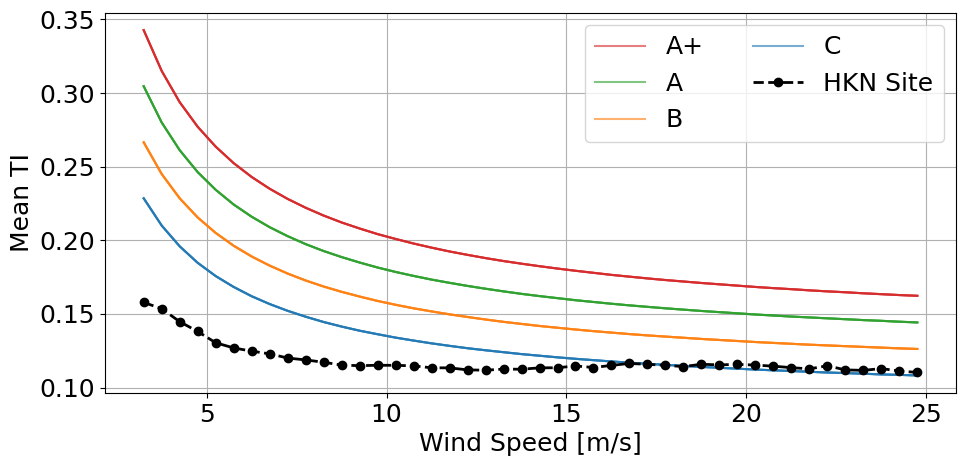

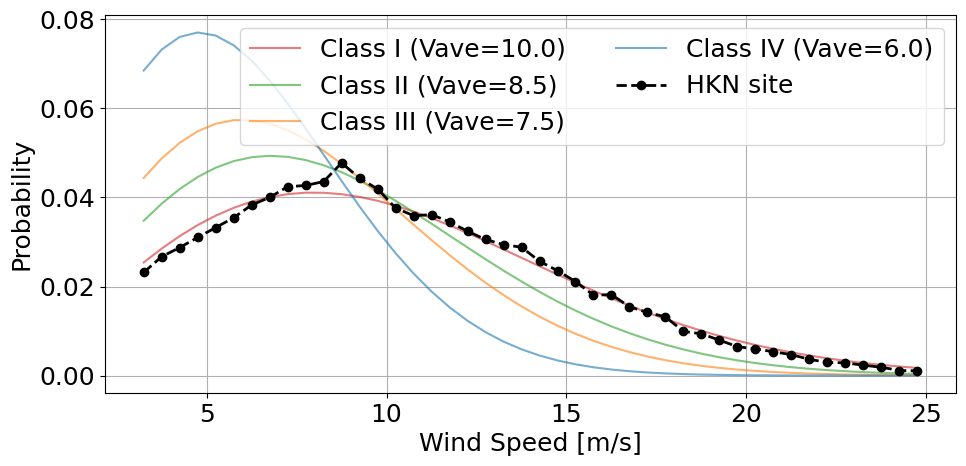

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Define IEC classes ---
IEC_CLASSES = {
    "IA+":   {"Vave": 10.0, "Vref": 50.0, "TIref": 0.18},
    "IA":    {"Vave": 10.0, "Vref": 50.0, "TIref": 0.16},
    "IB":    {"Vave": 10.0, "Vref": 50.0, "TIref": 0.14},
    "IC":    {"Vave": 10.0, "Vref": 50.0, "TIref": 0.12},
    "IIA+":  {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.18},
    "IIA":   {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.16},
    "IIB":   {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.14},
    "IIC":   {"Vave": 8.5,  "Vref": 42.5, "TIref": 0.12},
    "IIIA+": {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.18},
    "IIIA":  {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.16},
    "IIIB":  {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.14},
    "IIIC":  {"Vave": 7.5,  "Vref": 37.5, "TIref": 0.12},
    "IVA+":  {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.18},
    "IVA":   {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.16},
    "IVB":   {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.14},
    "IVC":   {"Vave": 6.0,  "Vref": 30.0, "TIref": 0.12},
}

# --- Prepare paths and bins ---
distribution_folder = Path("distributions")
iec_class_names = list(IEC_CLASSES.keys())
distribution_files = [distribution_folder / f"IEC_{name}_distribution.csv" for name in iec_class_names]

wsp_bins = np.arange(3, 25.5, 0.5)
wsp_centers = (wsp_bins[:-1] + wsp_bins[1:]) / 2

# --- Process your site data ---
df['wsp_bin_iec'] = pd.cut(df['wsp'], bins=wsp_bins, right=False)
ti_site = df.groupby('wsp_bin_iec', observed=True)['TI'].mean()
ti_site.index = wsp_centers[:len(ti_site)]
hist_counts, _ = np.histogram(df['wsp'], bins=wsp_bins)
site_pdf = hist_counts / hist_counts.sum()

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Plot 1: Average TI vs Wind Speed, grouped by TIref ---
import matplotlib.cm as cm

# --- Prepare color maps ---
ti_refs = sorted(set(props['TIref'] for props in IEC_CLASSES.values()))
ti_colors = dict(zip(ti_refs, cm.get_cmap('tab10').colors[:len(ti_refs)]))

vave_refs = sorted(set(props['Vave'] for props in IEC_CLASSES.values()))
vave_labels = {10.0: 'Class I', 8.5: 'Class II', 7.5: 'Class III', 6.0: 'Class IV'}
vave_colors = dict(zip(vave_refs, cm.get_cmap('tab10').colors[:len(vave_refs)]))

plt.rcParams.update({'font.size': 18})

# --- Plot 1: Average TI vs Wind Speed, grouped by TIref ---
plt.figure(figsize=(10, 5))
plotted_tiref = set()

for name, props in IEC_CLASSES.items():
    TIref = props['TIref']
    color = ti_colors[TIref]
    
    df_iec = pd.read_csv(distribution_folder / f"IEC_{name}_distribution.csv")
    avg_ti = df_iec.set_index("wsp")["TI"]

    # label = f"TIref = {TIref:.2f}" if TIref not in plotted_tiref else None
    # label = name if TIref not in plotted_tiref else None
    label = name.lstrip("IV") if TIref not in plotted_tiref else None


    plotted_tiref.add(TIref)

    plt.plot(avg_ti.index, avg_ti.values, color=color, alpha=0.6, label=label)

plt.plot(ti_site.index, ti_site.values, 'k--o', linewidth=2, label="HKN Site")

plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Mean TI")
# plt.title("Average TI vs Wind Speed (Grouped by TIref)")
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# --- Plot 2: Wind Speed Distribution, grouped by Vave ---
plt.figure(figsize=(10, 5))
plotted_vave = set()

for name, props in IEC_CLASSES.items():
    Vave = props['Vave']
    color = vave_colors[Vave]

    if Vave not in plotted_vave:
        label = f"{vave_labels[Vave]} (Vave={Vave})"
        plotted_vave.add(Vave)

        A = Vave * np.sqrt(2 / np.pi)
        wsp_pdf = (wsp_centers / A**2) * np.exp(-(wsp_centers**2) / (2 * A**2))
        wsp_pdf /= wsp_pdf.sum()

        plt.plot(wsp_centers, wsp_pdf, color=color, alpha=0.6, label=label)

plt.plot(wsp_centers, site_pdf, 'k--o', linewidth=2, label="HKN site")

plt.xlabel("Wind Speed [m/s]")
plt.ylabel("Probability")
# plt.title("Wind Speed Distribution (Grouped by Vave)")
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
